In [1]:
import math
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import poisson
from patsy import dmatrices
import statsmodels.graphics.tsaplots as tsa
from matplotlib import pyplot as plt
from statsmodels.tools.numdiff import approx_hess1, approx_hess2, approx_hess3
import scipy.optimize as opt


**Consul’s Generalized Poisson Regression Model (Generalized Poisson-1 Model, GP-1)**

In [2]:
def GP1_pmf(y, mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( 1/math.exp((mu + alpha*y) ) * mu * ( (mu + alpha*y)**(y-1) ) ) / (math.factorial(y))

def GP1_mean(mu, alpha):
        if(alpha == 1 ):
                return ( mu ) / (0.9)
        else:
                return ( mu ) / (1-alpha)

def GP1_var(mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( mu ) / (1-alpha)**3

In [3]:
GP1_pmf(4,3,1)

0.03909693927314988

In [4]:
class GP1HMM(GenericLikelihoodModel):
    #endog:Yt; exog: X list of emission; k: #state; covariate:corvariate list of transtion matrix;
    #length: list of mutlti time serial data length, e.g. [15,22,30]; extra_params_names: name of parameters
    def __init__(self, endog, exog, k_regimes=2, covariate = None , length=None,loglike=None, score=None, hessian=None,
                 missing='none', extra_params_names=None, **kwds):
        super(GP1HMM, self).__init__(endog=endog, exog=exog, loglike=loglike, score=score,
                                         hessian=hessian, missing=missing,
                                         extra_params_names=extra_params_names, kwds=kwds)
        #Initialize all variable

        self.y = np.array(self.endog)
        self.k_regimes = k_regimes
        if covariate is not None:
            self.covariate = np.array(covariate)
        if length is not None:
            self.length = np.array(length)
        else:
            self.length = None
        
        # 1 x (k_regimes-1) proxy of initial state probability matrix
        self.initial_state_matrix = np.ones([1, self.k_regimes-1])/k_regimes

        #k_regimes x corvariate.shape[1] size matrix of regime specific self-recurrent regression coefficients
        self.covariate_beta_matrix = np.ones([self.k_regimes, self.covariate.shape[1] ])

        # k x (k-2) matrix of psuedo transition probabilities which can range from -inf to +inf during
        # optimization. Initialized to 1.0/k-2
        if self.k_regimes>2:
            self.q_matrix = np.ones([self.k_regimes,(self.k_regimes-2)])*(1.0/ (self.k_regimes-2) )

        #k_regimes x exog.shape[1] size matrix of regime specific regression coefficients
        self.beta_matrix = np.ones([self.k_regimes, self.exog.shape[1]])

        #The regime wise matrix of Poisson means. These would be updated during the optimization
        # loop
        self.mu_matrix = []

        #The GP2 dispersion parameter.
        self.alpha = np.zeros([self.k_regimes,1])

        # (t-1) x k x k matrix of the real Markov transition probabilities which will be calculated from
        # the q-matrix using a standardization technique. Initialized to 1.0/k
        self.gamma_matrix = np.ones([self.exog.shape[0]-1, self.k_regimes, self.k_regimes])*(1.0/self.k_regimes)

        # The Markov state probabilities. Also referred to as pi. but we'll use delta since pi is
        # often used to refer to the mean
        self.delta_matrix = np.ones([self.exog.shape[0],self.k_regimes])*(1.0/self.k_regimes)

        #A very tiny number (machine specific). Used by the LL function.
        self.EPS = np.MachAr().eps

        #Optimization iteration counter
        self.iter_num=0

        #The vector of initial values for all the parameters, beta and q, that the optimizer will
        # optimize
        self.start_params = self.beta_matrix.flatten()
        self.start_params = np.append(self.start_params, self.initial_state_matrix.flatten())
        self.start_params = np.append(self.start_params, self.covariate_beta_matrix.flatten())

        if k_regimes>2:
            self.start_params = np.append(self.start_params, self.q_matrix.flatten())

        self.ll_history = np.zeros([1,1])
        self.params_history = np.zeros([1,len(self.start_params)])

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeobs(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP2 dispersion parameter
        self.compute_GP2_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))))

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)

        #Return the negated array of  log-likelihood values
        return -ll

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeopt(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP2 dispersion parameter
        self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))))

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)

        #Return the negated array of  log-likelihood values
        return -ll.sum()

    # Reconstitute the q and beta matrices from the current values of all the params
    def reconstitute_parameter_matrices(self, params):
        index = 0

        self.beta_matrix = params[ : self.k_regimes*self.exog.shape[1] ]
        self.beta_matrix = self.beta_matrix.reshape([self.k_regimes, self.exog.shape[1] ]) 
        index = index + self.k_regimes*self.exog.shape[1]
        
        self.initial_state_matrix = params[index : index + self.k_regimes - 1 ]
        self.initial_state_matrix = self.initial_state_matrix.reshape([1, self.k_regimes-1])
        index = index + self.k_regimes - 1

        self.covariate_beta_matrix = params[index : index + self.k_regimes * self.covariate.shape[1]]
        self.covariate_beta_matrix = self.covariate_beta_matrix.reshape([self.k_regimes, self.covariate.shape[1] ])
        index = index + self.k_regimes * self.covariate.shape[1]
            
        if self.k_regimes>2:
            self.q_matrix = params[index : index + self.k_regimes*(self.k_regimes-2)]
            self.q_matrix = self.q_matrix.reshape([self.k_regimes, (self.k_regimes-2)])

    # Build the regime wise matrix of Poisson means
    def compute_regime_specific_poisson_means(self):
        self.mu_matrix = []
        '''for k in range(1, self.k_regimes):
            self.beta_matrix[k][0] += np.exp(self.beta_matrix[k-1][0])'''

        for j in range(self.k_regimes):
            #Fetch the regression coefficients vector corresponding to the jth regime
            beta_j = self.beta_matrix[j]

            #Compute the Poisson mean and variance
            mu_j = np.exp(self.exog.dot(beta_j))
 

            if len(self.mu_matrix) == 0:
                self.mu_matrix = mu_j
            else:
                self.mu_matrix = np.vstack((self.mu_matrix,mu_j))


                
        self.mu_matrix = self.mu_matrix.transpose()
    
    # Compute the GP2 dispersion parameter
    def compute_GP1_alpha(self):

        N = len(self.y)*self.k_regimes
        k = self.beta_matrix.shape[1]
        sum = 0

        for i in range(self.k_regimes):
            for j in range(len(self.y)):
                sum += ( np.abs(self.y[j] - self.mu_matrix[j][i]) / ( (self.mu_matrix[j][i])**(1/2) ) - 1 )* (self.mu_matrix[j][i]**(-1))
            self.alpha[i] = sum / (N-k-1)


            
            if(self.alpha[i] <= (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) ):    
                self.alpha[i] = (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) + np.MachAr().eps
            elif(self.alpha[i] >= 1 ):
                self.alpha[i] = 1
        






    # Build the matrix of Markov transition probabilities by computing self-recurrent and non-recurrent state probabilities
    def compute_markov_transition_probabilities(self):
        
        # t x k recurrent matrix compute state k transition to itself in every time t
        self.recurrent_matrix = (self.covariate.dot(self.covariate_beta_matrix.transpose()))
        for t in range(self.exog.shape[0]-1):
            for i in range(self.k_regimes):
                for j in range(self.k_regimes):
                    if(i==j):
                        if(self.recurrent_matrix[t][j]>=709):
                            self.recurrent_matrix[t][j]=709
                        self.gamma_matrix[t][i][j] = math.exp(self.recurrent_matrix[t][j]) /( 1 + math.exp(self.recurrent_matrix[t][j]) )

        # If k=2, there's no need to use q_matrix
        if(self.k_regimes==2):
            for t in range(self.exog.shape[0]-1):
                for i in range(self.k_regimes):
                    for j in range(self.k_regimes):
                        if(i!=j):
                            self.gamma_matrix[t][i][j] = 1 - self.gamma_matrix[t][i][i]
        else:
            for t in range(self.exog.shape[0]-1):
                #Using  q to compute transtion probability which is not self-recurrent
                for i in range(self.k_regimes):
                    denom = 1
                    count = 0
                    for r in range(self.k_regimes-2):
                        denom += math.exp(self.q_matrix[i][r])
                        
                    for j in range(self.k_regimes):            
                        if(i==j ):continue
                        else:
                            if(count < self.k_regimes-2):
                                self.gamma_matrix[t][i][j] =( math.exp(self.q_matrix[i][count])/denom)*(1-self.gamma_matrix[t][i][i])
                                count+=1
                            else:
                                self.gamma_matrix[t][i][j] = (1.0/denom)*(1-self.gamma_matrix[t][i][i])

    # Build the (t x k) matrix delta of Markov state probabilities distribution. k state
    # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
    def compute_markov_state_probabilities(self):
        #Compute initial state probability
        denom = 1
        for r in range(self.k_regimes-1):
            if(self.initial_state_matrix[0][r]>709):
                self.initial_state_matrix[0][r] = 709
            denom += math.exp(self.initial_state_matrix[0][r])
            
        for j in range(self.k_regimes-1):
            self.delta_matrix[0][j] = math.exp(self.initial_state_matrix[0][j])/denom
        self.delta_matrix[0][self.k_regimes-1] = 1.0/denom

        #Compute state probabilties in each time t seperately if there's multiple time serial data.
        if(self.length is not None):
            index = 1
            for n in range(len(self.length)):
                for t in range(index, index + self.length[n] - 1):
                    self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])
                index += self.length[n]
                if (index-1) < len(self.y):
                    self.delta_matrix[index-1]= self.delta_matrix[0]
        else:
            for t in range(1, len(self.y)):
                self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])


    # Compute all the log-likelihood values for the Poisson Markov model
    def compute_loglikelihood(self):
        #Init the list of loglikelihhod values, one value for each y observation
        ll = []
        for t in range(len(self.y)):
            prob_y_t = 0
            mu_t = 0
            for j in range(self.k_regimes):
                #To use the law of total probability, uncomment this row and comment out the next
                # two rows

                prob_y_t += GP1_pmf(self.y[t], self.mu_matrix[t][j], self.alpha[j] ) * self.delta_matrix[t][j]
                #Calculate the Poisson mean mu_t as an expectation over all Markov state
                # probabilities
                #mu_t += self.mu_matrix[t][j] * self.delta_matrix[t][j]
                #prob_y_t += poisson.pmf(self.y[t], mu_t)

            #This is a bit of a kludge. If the likelihood turns out to be real tiny, fix it to
            # the EPS value for the machine
            if prob_y_t < self.EPS:
                prob_y_t = self.EPS
            #Push the LL into the list of LLs
            ll.append(math.log(prob_y_t))
        ll = np.array(ll)
        return ll
    
    #Decode state path
    def decode(self):
        #decoded state path matrix: t
        self.decode_matrix = np.ones([len(self.y)])
        for t in range( len(self.y) ):
            max = 0
            state = 0
            for k in range(self.k_regimes):
                if(k == 0):
                    max = self.delta_matrix[t][k]
                    state = state + 1
                else:
                    if(self.delta_matrix[t][k] > max):
                        state = state + 1
                        max = self.delta_matrix[t][k]
            self.decode_matrix[t] = state

    #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
    # using selection sort.
    def sort(self):
        for i in range(self.k_regimes-1):
            minimum = i
            for j in range(i+1,self.k_regimes):
                if( self.beta_matrix[minimum][0] > self.beta_matrix[j][0] ):
                    minimum = j
            if(minimum != i):
                self.beta_matrix = list(self.beta_matrix)
                self.beta_matrix[minimum], self.beta_matrix[i] =  self.beta_matrix[i], self.beta_matrix[minimum]
                self.beta_matrix = np.array(self.beta_matrix)

                self.covariate_beta_matrix = list(self.covariate_beta_matrix)
                self.covariate_beta_matrix[minimum], self.covariate_beta_matrix[i] = self.covariate_beta_matrix[i], self.covariate_beta_matrix[minimum]
                self.covariate_beta_matrix = np.array(self.covariate_beta_matrix)

                self.delta_matrix = list(self.delta_matrix)
                self.mu_matrix = list(self.mu_matrix)

                for t in range(len(self.y)):
                    self.delta_matrix[t][minimum], self.delta_matrix[t][i] =  self.delta_matrix[t][i], self.delta_matrix[t][minimum]
                    self.mu_matrix[t][minimum], self.mu_matrix[t][i] =  self.mu_matrix[t][i], self.mu_matrix[t][minimum]
                self.delta_matrix = np.array(self.delta_matrix)
                self.mu_matrix = np.array(self.mu_matrix)

                self.gamma_matrix = list(self.gamma_matrix) 
                for t in range(len(self.y)-1):
                    self.gamma_matrix[t][minimum][minimum], self.gamma_matrix[t][i][i] = self.gamma_matrix[t][i][i], self.gamma_matrix[t][minimum][minimum]
                    self.gamma_matrix[t][minimum][i], self.gamma_matrix[t][i][minimum] = self.gamma_matrix[t][i][minimum], self.gamma_matrix[t][minimum][i]
                self.gamma_matrix = np.array(self.gamma_matrix)

                
                

In [5]:
k_regimes = 2

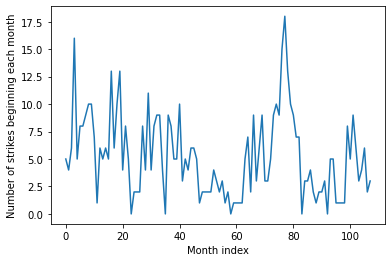

In [6]:
strikes_dataset = sm.datasets.get_rdataset(dataname="StrikeNb", package = "Ecdat")
strikes_data = strikes_dataset.data

#Plot the number of strikes starting each month
plt.xlabel('Month index')
plt.ylabel('Number of strikes beginning each month')
strikes_data['strikes'].plot()
plt.show()

In [7]:
strikes_data['strikes_lag1'] = strikes_data['strikes'].shift(1)
strikes_data = strikes_data.dropna()

def indicator_func(x):
    if x == 0:
        return 1
    else:
        return 0

strikes_data['d1'] = strikes_data['strikes_lag1'].apply(indicator_func)
strikes_data['strikes_adj_lag1']=np.maximum(1,strikes_data['strikes_lag1'])
strikes_data['ln_strike_adj_lag1']=np.log(strikes_data['strikes_adj_lag1']) 

expr = 'strikes ~ output + ln_strike_adj_lag1 + d1'
y_train, x_train = dmatrices(expr, strikes_data, return_type='dataframe')

C:\Users\s9421\AppData\Local\Temp/ipykernel_5404/3195480036.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strikes_data['d1'] = strikes_data['strikes_lag1'].apply(indicator_func)
C:\Users\s9421\AppData\Local\Temp/ipykernel_5404/3195480036.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strikes_data['strikes_adj_lag1']=np.maximum(1,strikes_data['strikes_lag1'])
C:\Users\s9421\AppData\Local\Temp/ipykernel_5404/3195480036.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [8]:
cor = 'strikes ~ output + ln_strike_adj_lag1 + d1 '
y, covariate = dmatrices(cor, strikes_data, return_type='dataframe')

In [9]:
k_regimes = 2
extra_params_names = []

for regime_num in range(1, k_regimes):
    for param_name in x_train.columns:
        extra_params_names.append(param_name+'_R'+str(regime_num))

for k in range(k_regimes-1):
    extra_params_names.append('Initial state_'+str(k))

for regime_num in range(k_regimes):
#    extra_params_names.append("Intercept_"+str(regime_num))
    for param_name in covariate.columns:
        extra_params_names.append(param_name+"_"+str(regime_num))
    

#for i in range(k_regimes):
#    for j in range(k_regimes-2):
#        extra_params_names.append('q_'+str(i)+str(j))

In [10]:
gp1_hmm = GP1HMM(endog=y_train, exog=x_train, covariate=covariate,
                        k_regimes=k_regimes,length=[len(y_train)],
                        extra_params_names=extra_params_names)

params = gp1_hmm.start_params           
             
res=opt.minimize(gp1_hmm.nloglikeopt,params, method='Nelder-Mead')



#gp1_hmm_results = gp1_hmm.fit(method='bfgs', maxiter=400)

ITER=1 ll=761.8385194040555
ITER=2 ll=786.1473931647772
ITER=3 ll=762.0021738965403
ITER=4 ll=797.3006568430058
ITER=5 ll=762.2793496437413
ITER=6 ll=780.4642008319918
ITER=7 ll=761.9192556692685
ITER=8 ll=787.9720458218985
ITER=9 ll=762.2455431190677
ITER=10 ll=761.8313454163269
ITER=11 ll=761.7105337518047
ITER=12 ll=761.8366168885362
ITER=13 ll=761.6864389700567
ITER=14 ll=761.8332148196309
ITER=15 ll=761.9605949649622
ITER=16 ll=761.8403346619114
ITER=17 ll=761.981978623898
ITER=18 ll=761.8437989854165
ITER=19 ll=697.2785764614292
ITER=20 ll=624.482196203544
ITER=21 ll=701.0473509627586
ITER=22 ll=710.8668458009606
ITER=23 ll=716.4660509054635
ITER=24 ll=732.6392830568199
ITER=25 ll=729.154920415805
ITER=26 ll=725.3846650296344
ITER=27 ll=720.7704608336919
ITER=28 ll=715.8727349567713
ITER=29 ll=710.8158417349468
ITER=30 ll=704.6913017117587
ITER=31 ll=697.91043415366
ITER=32 ll=690.3590496347867
ITER=33 ll=681.9605865007824
ITER=34 ll=672.6436227872035
ITER=35 ll=662.3213742589215

In [11]:
while(res.success!=1):
    res=opt.minimize(gp1_hmm.nloglikeopt,res.x, method='Nelder-Mead')

ITER=3401 ll=259.9054629214897
ITER=3402 ll=259.8978794817782
ITER=3403 ll=259.93946947777965
ITER=3404 ll=260.0521283579126
ITER=3405 ll=259.93213557001343
ITER=3406 ll=260.60830292660415
ITER=3407 ll=259.90335647716614
ITER=3408 ll=259.93695213087875
ITER=3409 ll=259.91001395961814
ITER=3410 ll=259.9012162756265
ITER=3411 ll=259.93992660586264
ITER=3412 ll=259.9005758829304
ITER=3413 ll=259.9052531158041
ITER=3414 ll=259.9097399393279
ITER=3415 ll=259.9457053798301
ITER=3416 ll=259.89052349105265
ITER=3417 ll=259.93346796252735
ITER=3418 ll=259.9058636119087
ITER=3419 ll=260.3240242752745
ITER=3420 ll=259.979712004086
ITER=3421 ll=260.16619561368344
ITER=3422 ll=259.9218240880249
ITER=3423 ll=260.11347704234385
ITER=3424 ll=259.9091119612116
ITER=3425 ll=259.95800050995723
ITER=3426 ll=259.91388933358473
ITER=3427 ll=259.9277684001168
ITER=3428 ll=259.8766078557887
ITER=3429 ll=259.8609005231775
ITER=3430 ll=259.881451563789
ITER=3431 ll=259.88965968574587
ITER=3432 ll=259.8668831647

In [12]:
print(res)

 final_simplex: (array([[  0.345689  ,  -1.52842565,   0.50569653,   1.16108988,
          1.57928911,   0.18573144,   0.22518796,  -0.86644961,
         -2.00528823,   2.41689136, -18.71206237,  41.02655648,
         26.9632331 ,   5.89952976,  41.34152313,  -1.02689064,
         -4.34779241],
       [  0.345689  ,  -1.52842565,   0.50569653,   1.16108988,
          1.57928911,   0.18573144,   0.22518796,  -0.86644961,
         -2.00528823,   2.41689136, -18.71206237,  41.02655194,
         26.96322192,   5.89952976,  41.34152313,  -1.02689064,
         -4.34779241],
       [  0.345689  ,  -1.52842565,   0.50569653,   1.16108988,
          1.57928911,   0.18573144,   0.22518796,  -0.86644961,
         -2.00528823,   2.41689136, -18.71206237,  41.02654542,
         26.96324853,   5.89952976,  41.34152313,  -1.02689064,
         -4.34779241],
       [  0.345689  ,  -1.52842565,   0.50569653,   1.16108988,
          1.57928911,   0.18573144,   0.22518796,  -0.86644961,
         -2.005288

In [13]:
gp1_hmm.sort()
'''(gp1_hmm_results.params = gp1_hmm.beta_matrix.flatten()
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.initial_state_matrix.flatten())
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.covariate_beta_matrix.flatten())
if k_regimes>2:
    gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.q_matrix.flatten()))'''
    
print('Mean of transition matrix:')
print(np.mean(gp1_hmm.gamma_matrix,axis = 0))

Mean of transition matrix:
[[0.98392114 0.01607886]
 [0.09618253 0.90381747]]


In [14]:
#print(gp1_hmm_results.summary())

**Emission Coefficient**

In [15]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.beta_matrix.shape[1]):
        print(x_train.columns[i],str(k + 1)+':',np.round(gp1_hmm.beta_matrix[k][i], decimals=2),end='. ')
    print('')



Intercept 1: 0.35. output 1: -1.53. ln_strike_adj_lag1 1: 0.51. d1 1: 1.16. 
Intercept 2: 1.58. output 2: 0.19. ln_strike_adj_lag1 2: 0.23. d1 2: -0.87. 


**Covariate coefficient:**

In [16]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.covariate_beta_matrix.shape[1]):
        print(covariate.columns[i],str(k + 1)+':',np.round(gp1_hmm.covariate_beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: 2.42. output 1: -18.71. ln_strike_adj_lag1 1: 41.03. d1 1: 26.96. 
Intercept 2: 5.9. output 2: 41.34. ln_strike_adj_lag1 2: -1.03. d1 2: -4.35. 


**Initial state probability:**

In [17]:
for k in range(k_regimes):
    print('State '+str(k + 1)+':',np.round(gp1_hmm.delta_matrix[0][k], decimals=8),end='. ')


State 1: 0.11864881. State 2: 0.88135119. 

In [18]:
gp1_hmm.decode()

In [19]:
state_specific_mu = np.zeros([107])
for t in range(107):
    if (gp1_hmm.decode_matrix[t] == 1):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][0]/(1-gp1_hmm.alpha[0])
    elif(gp1_hmm.decode_matrix[t] == 2):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][1]/(1-gp1_hmm.alpha[1])
    else:
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][2]/(1-gp1_hmm.alpha[2])
    

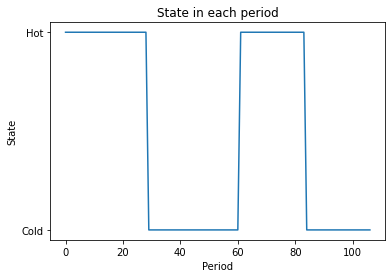

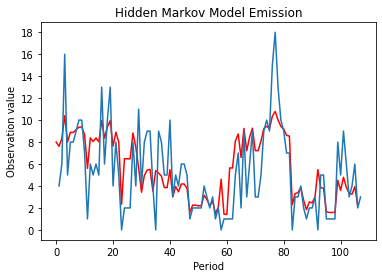

In [20]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2],['Cold','Hot'])
plt.plot(range(107),gp1_hmm.decode_matrix)
plt.show()

#Plot the mu_2 each month

plt.plot(range(107),state_specific_mu,'r')


#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
strikes_data['strikes'].plot()
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

**MAE**

In [21]:
np.abs(state_specific_mu-strikes_data['strikes']).mean()

2.3681687399984113

In [22]:
-(gp1_hmm.ll_history[-1])*2+gp1_hmm.start_params.shape[0]*2

array([542.17123832])

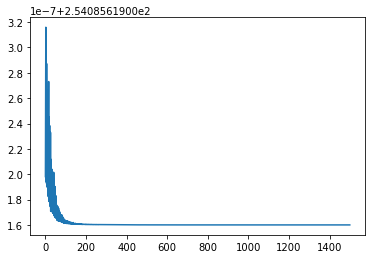

In [31]:
plt.plot(range(1500), -gp1_hmm.ll_history[-1500:])
plt.show()